In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df  = pd.read_csv('Inventory Dataset.csv')
df.head()

,RegionName,CountryName,State,City,PostalCode,WarehouseAddress,WarehouseName,EmployeeName,EmployeeEmail,EmployeePhone,...,CustomerName,CustomerAddress,CustomerCreditLimit,CustomerEmail,CustomerPhone,Status,OrderDate,OrderItemQuantity,PerUnitPrice,TotalItemQuantity
0,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Summer Payne,summer.payne@example.com,5151238181,...,Flor Stone,2904 S Salina St,5000,flor.stone@raytheon.com,13171234104,Shipped,17-Nov-16,132,469.99,122
1,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Rose Stephens,rose.stephens@example.com,5151238080,...,Lavera Emerson,"5344 Haverford Ave, Philadelphia",5000,lavera.emerson@plainsallamerican.com,13171234111,Shipped,20-Feb-17,124,519.99,123
2,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Annabelle Dunn,annabelle.dunn@example.com,5151234444,...,Fern Head,"1795 Wu Meng, Muang Chonburi",1200,fern.head@usfoods.com,18121234115,Canceled,03-Jan-17,92,800.74,123
3,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Tommy Bailey,tommy.bailey@example.com,5151234567,...,Shyla Ortiz,"Walpurgisstr 69, Munich",2400,shyla.ortiz@abbvie.com,13171234126,Pending,15-Oct-17,128,849.99,124
4,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Blake Cooper,blake.cooper@example.com,5151234569,...,Jeni Levy,"Via Frenzy 6903, Roma",1200,jeni.levy@centene.com,18121214129,Shipped,09-Apr-17,106,109.99,125


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RegionName           400 non-null    object 
 1   CountryName          400 non-null    object 
 2   State                400 non-null    object 
 3   City                 400 non-null    object 
 4   PostalCode           400 non-null    object 
 5   WarehouseAddress     400 non-null    object 
 6   WarehouseName        400 non-null    object 
 7   EmployeeName         400 non-null    object 
 8   EmployeeEmail        400 non-null    object 
 9   EmployeePhone        400 non-null    int64  
 10  EmployeeHireDate     400 non-null    object 
 11  EmployeeJobTitle     400 non-null    object 
 12  CategoryName         400 non-null    object 
 13  ProductName          400 non-null    object 
 14  ProductDescription   400 non-null    object 
 15  ProductStandardCost  400 non-null    flo

In [5]:
df.isnull().sum()

RegionName             0
CountryName            0
State                  0
City                   0
PostalCode             0
WarehouseAddress       0
WarehouseName          0
EmployeeName           0
EmployeeEmail          0
EmployeePhone          0
EmployeeHireDate       0
EmployeeJobTitle       0
CategoryName           0
ProductName            0
ProductDescription     0
ProductStandardCost    0
Profit                 0
ProductListPrice       0
CustomerName           0
CustomerAddress        0
CustomerCreditLimit    0
CustomerEmail          0
CustomerPhone          0
Status                 0
OrderDate              0
OrderItemQuantity      0
PerUnitPrice           0
TotalItemQuantity      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,EmployeePhone,ProductStandardCost,Profit,ProductListPrice,CustomerCreditLimit,CustomerPhone,OrderItemQuantity,PerUnitPrice,TotalItemQuantity
count,4.000000e+02,400.000000,400.000000,400.000000,400.000000,4.000000e+02,400.000000,400.000000,400.000000
mean,1.300551e+12,1812.654525,189.743700,2002.398800,2033.617500,6.422348e+10,89.240000,839.253100,123.695000
std,3.546655e+12,4297.988742,254.318871,4432.591249,1534.488065,1.871854e+11,34.064253,706.449917,67.438876
min,1.856490e+07,12.630000,0.000000,15.550000,100.000000,4.538500e+04,32.000000,16.990000,0.000000
25%,9.716165e+08,414.160000,59.972500,502.982500,700.000000,3.545837e+09,61.000000,352.982500,92.750000
50%,1.168870e+10,698.320000,134.200000,849.990000,1500.000000,9.800588e+09,85.500000,686.990000,123.000000
75%,2.651186e+10,1671.950000,229.520000,1999.890000,3500.000000,1.812122e+10,118.000000,1055.990000,178.000000
max,1.144164e+13,75410.000000,2770.000000,78180.000000,5000.000000,9.138593e+11,157.000000,4139.000000,353.000000


In [8]:
df['EmployeeHireDate'] = pd.to_datetime(df['EmployeeHireDate'])
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

df['EmployeePhone'] = df['EmployeePhone'].astype(str)


C:\Users\goura\AppData\Local\Temp\ipykernel_6580\3595428524.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['EmployeeHireDate'] = pd.to_datetime(df['EmployeeHireDate'])
C:\Users\goura\AppData\Local\Temp\ipykernel_6580\3595428524.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['OrderDate'] = pd.to_datetime(df['OrderDate'])


In [9]:
(df['Profit'] < 0).sum()
(df['ProductListPrice'] < df['ProductStandardCost']).sum()
(df['OrderItemQuantity'] <= 0).sum()


np.int64(0)

# Create Derived / Business Columns (FEATURE ENGINEERING)

In [10]:
df['TotalRevenue'] = df['OrderItemQuantity'] * df['PerUnitPrice']
df['ProfitMargin'] = df['Profit'] / df['TotalRevenue']

df['OrderYear'] = df['OrderDate'].dt.year
df['OrderMonth'] = df['OrderDate'].dt.month
df['OrderQuarter'] = df['OrderDate'].dt.to_period('Q')

df['EmployeeTenureYears'] = (
    (df['OrderDate'] - df['EmployeeHireDate']).dt.days / 365
)


In [11]:
df.head()

,RegionName,CountryName,State,City,PostalCode,WarehouseAddress,WarehouseName,EmployeeName,EmployeeEmail,EmployeePhone,...,OrderDate,OrderItemQuantity,PerUnitPrice,TotalItemQuantity,TotalRevenue,ProfitMargin,OrderYear,OrderMonth,OrderQuarter,EmployeeTenureYears
0,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Summer Payne,summer.payne@example.com,5151238181,...,2016-11-17,132,469.99,122,62038.68,0.008752,2016,11,2016Q4,0.446575
1,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Rose Stephens,rose.stephens@example.com,5151238080,...,2017-02-20,124,519.99,123,64478.76,0.006959,2017,2,2017Q1,0.706849
2,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Annabelle Dunn,annabelle.dunn@example.com,5151234444,...,2017-01-03,92,800.74,123,73668.08,0.008491,2017,1,2017Q1,0.295890
3,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Tommy Bailey,tommy.bailey@example.com,5151234567,...,2017-10-15,128,849.99,124,108798.72,0.003774,2017,10,2017Q4,1.328767
4,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Blake Cooper,blake.cooper@example.com,5151234569,...,2017-04-09,106,109.99,125,11658.94,0.041992,2017,4,2017Q2,1.238356


# 🔹 STEP 4: CORE EDA (THIS IS YOUR MAIN CONTENT)
1️⃣ Product & Category Analysis (Inventory Core)

In [12]:
df.groupby('ProductName')['TotalItemQuantity'].sum().sort_values(ascending=False)

df.groupby('CategoryName')['Profit'].sum().sort_values(ascending=False)


CategoryName
CPU             24567.20
Video Card      20036.15
RAM             14671.00
Storage         10888.06
Mother Board     5735.07
Name: Profit, dtype: float64

# Revenue & Profit Analysis

In [13]:
df.groupby('ProductName')['TotalRevenue'].sum().nlargest(10)
df.groupby('RegionName')['Profit'].sum()

RegionName
Asia              17486.31
Australia          1442.32
North  America    31125.79
North America     11661.62
South America     14181.44
Name: Profit, dtype: float64

# Warehouse Performance (VERY IMPORTANT)

In [14]:
df.groupby('WarehouseName').agg({
    'TotalItemQuantity':'sum',
    'TotalRevenue':'sum',
    'Profit':'sum'
})


,TotalItemQuantity,TotalRevenue,Profit
WarehouseName,,,
Beijing,8461,2943211.19,10348.09
Bombay,8001,3469394.07,7138.22
Mexico City,6686,4850774.35,11498.05
New Jersy,976,3821020.40,8524.89
San Francisco,1386,2742251.82,12539.70
Seattle Washington,5770,3184680.56,6406.94
Southlake Texas,6448,2707261.23,14181.44
Sydney,5541,3704306.45,1442.32
Toronto,6209,3097190.64,3817.83


# Regional Analysis (Geo + Strategy)

In [15]:
# Regional Analysis (Geo + Strategy)
df.groupby(['CountryName','State','City'])['TotalRevenue'].sum()


CountryName               State             City               
Australia                 New South Wales   Sydney                 3704306.45
Canada                    Ontario           Toronto                3097190.64
China                     Beijing           Beijing                2943211.19
India                     Maharashtra       Bombay                 3469394.07
Mexico                    Distrito Federal  Mexico City            4850774.35
United States of America  California        South San Francisco    2742251.82
                          New Jersey        South Brunswick        3821020.40
                          Texas             Southlake              2707261.23
                          Washington        Seattle                3184680.56
Name: TotalRevenue, dtype: float64

# Customer Analysis (Revenue Drivers)

In [16]:
df.groupby('CustomerName')['TotalRevenue'].sum().nlargest(10)


CustomerName
Shields Seffi         600155.00
Bill Stein            550487.00
Daina Combs           389855.70
Mac Mckay             344872.35
Alessandra Estrada    328038.42
Samara Barnett        323400.00
Darron Robertson      307683.51
Glinda Lambert        302398.88
Herman Stokes         300139.18
Reva Fuller           292382.07
Name: TotalRevenue, dtype: float64

In [17]:
df['CustomerSegment'] = pd.qcut(
    df['TotalRevenue'], 
    q=3, 
    labels=['Low','Medium','High']
)


# Employee Performance Analysis (HR + Ops)

In [18]:
# Employee Performance Analysis (HR + Ops)
df.groupby('EmployeeName')['TotalRevenue'].sum()
df.groupby('EmployeeJobTitle')['Profit'].mean()


EmployeeJobTitle
Accountant                         228.027500
Accounting Manager                 288.365000
Administration Assistant           260.722500
Administration Vice President      257.503750
Finance Manager                    268.640000
Human Resources Representative     257.215000
Marketing Manager                  249.415000
Marketing Representative           179.107500
President                          231.010000
Programmer                         254.746500
Public Accountant                  313.097500
Public Relations Representative    192.860000
Purchasing Clerk                   133.732000
Purchasing Manager                 106.725000
Sales Manager                      132.447000
Sales Representative               103.617917
Shipping Clerk                     229.327463
Stock Clerk                        257.313788
Stock Manager                      246.734737
Name: Profit, dtype: float64

# Pricing & Profitability Analysis

In [19]:
df[['PerUnitPrice','OrderItemQuantity','Profit','TotalRevenue']].corr()


,PerUnitPrice,OrderItemQuantity,Profit,TotalRevenue
PerUnitPrice,1.000000,0.058542,-0.029464,0.856630
OrderItemQuantity,0.058542,1.000000,0.075729,0.443574
Profit,-0.029464,0.075729,1.000000,0.016920
TotalRevenue,0.856630,0.443574,0.016920,1.000000


# 8️⃣ Order Status Analysis (Operations)

In [20]:
df['Status'].value_counts(normalize=True) * 100


Status
Shipped     45.75
Canceled    27.75
Pending     26.50
Name: proportion, dtype: float64

In [21]:
top_products = (
    df.groupby('ProductName', as_index=False)['TotalRevenue']
      .sum()
      .sort_values(by='TotalRevenue', ascending=False)
      .head(10)
)


# Visual EDA (Python)

<Axes: xlabel='OrderMonth', ylabel='TotalRevenue'>

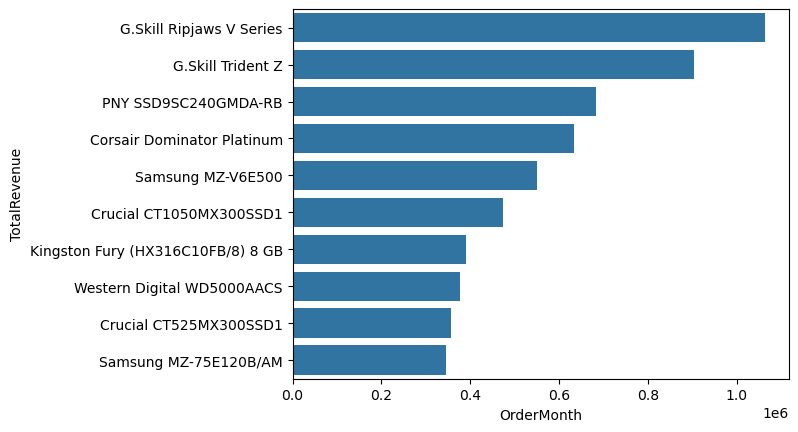

In [22]:
sns.lineplot(data=df, x='OrderMonth', y='TotalRevenue')
sns.barplot(data=top_products, x='TotalRevenue', y='ProductName')


# Category-wise Profit Distribution (Boxplot)

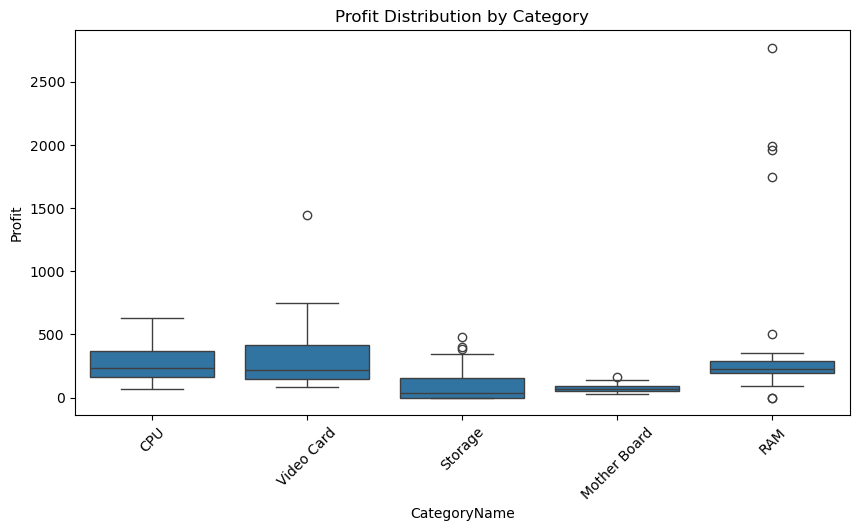

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='CategoryName', y='Profit')
plt.xticks(rotation=45)
plt.title('Profit Distribution by Category')
plt.show()


# Warehouse Performance Comparison (Bar Chart)

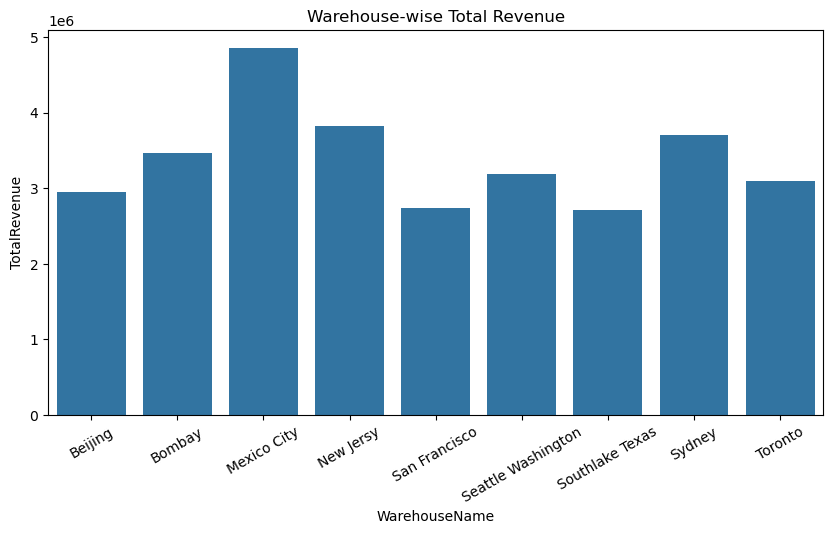

In [24]:
warehouse_perf = df.groupby('WarehouseName', as_index=False).agg({
    'TotalRevenue':'sum',
    'Profit':'sum'
})

plt.figure(figsize=(10,5))
sns.barplot(data=warehouse_perf, x='WarehouseName', y='TotalRevenue')
plt.title('Warehouse-wise Total Revenue')
plt.xticks(rotation=30)
plt.show()


# Region-wise Revenue Heatmap 🌍

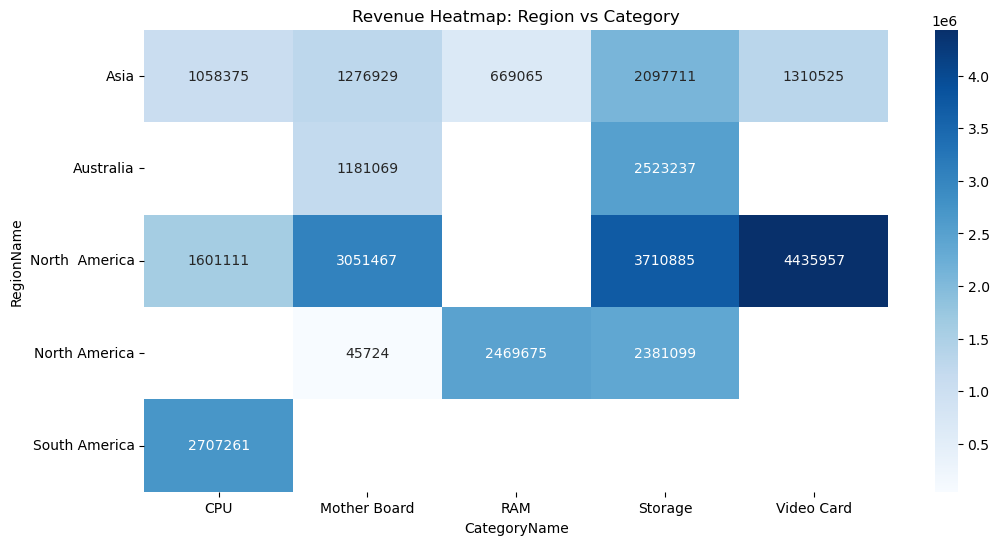

In [25]:
region_pivot = df.pivot_table(
    values='TotalRevenue',
    index='RegionName',
    columns='CategoryName',
    aggfunc='sum'
)

plt.figure(figsize=(12,6))
sns.heatmap(region_pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Revenue Heatmap: Region vs Category')
plt.show()


# 4️⃣ Price vs Demand Analysis (Scatter Plot)

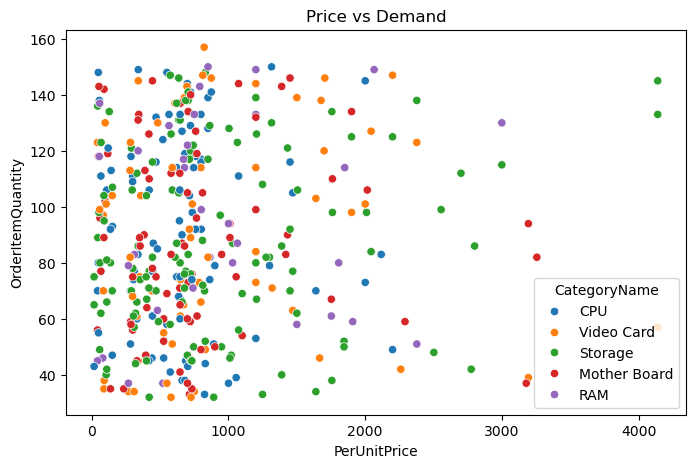

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='PerUnitPrice',
    y='OrderItemQuantity',
    hue='CategoryName'
)
plt.title('Price vs Demand')
plt.show()


# Monthly Sales Trend by Category (Line Chart)

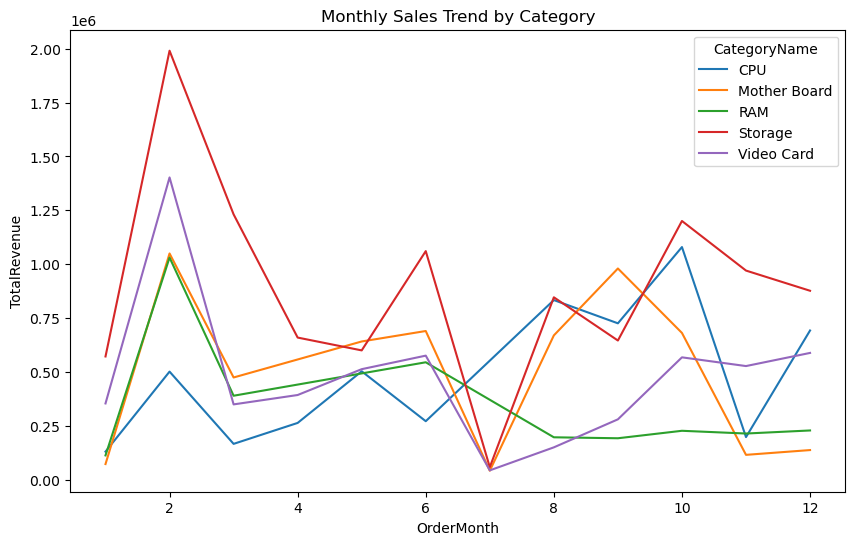

In [27]:
monthly_cat_sales = df.groupby(
    ['OrderMonth','CategoryName'], as_index=False
)['TotalRevenue'].sum()

plt.figure(figsize=(10,6))
sns.lineplot(
    data=monthly_cat_sales,
    x='OrderMonth',
    y='TotalRevenue',
    hue='CategoryName'
)
plt.title('Monthly Sales Trend by Category')
plt.show()


# Customer Segmentation Visualization (Countplot)

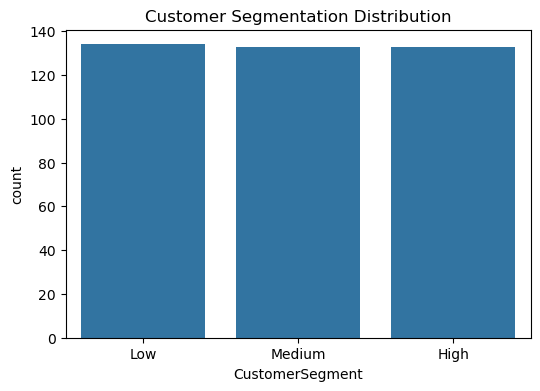

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='CustomerSegment')
plt.title('Customer Segmentation Distribution')
plt.show()


# Employee Experience vs Revenue (Scatter)

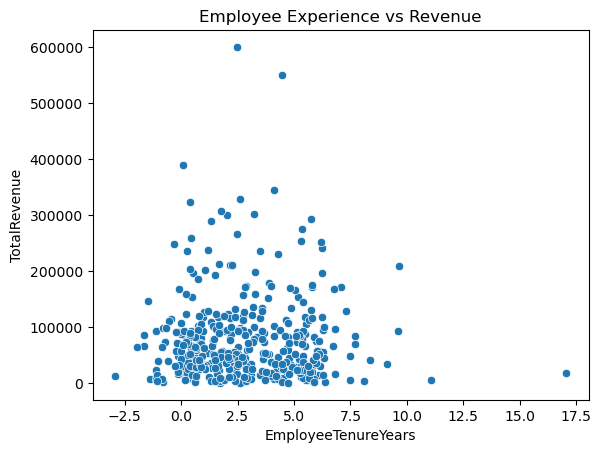

In [29]:
# plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='EmployeeTenureYears',
    y='TotalRevenue'
)
plt.title('Employee Experience vs Revenue')
plt.show()
 

# 8️⃣ Order Status Distribution (Pie / Donut)

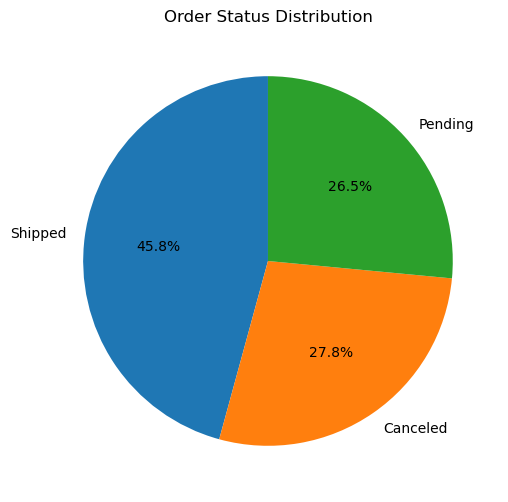

In [30]:
status_counts = df['Status'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Order Status Distribution')
plt.show()


# Profit Margin Analysis (Histogram)

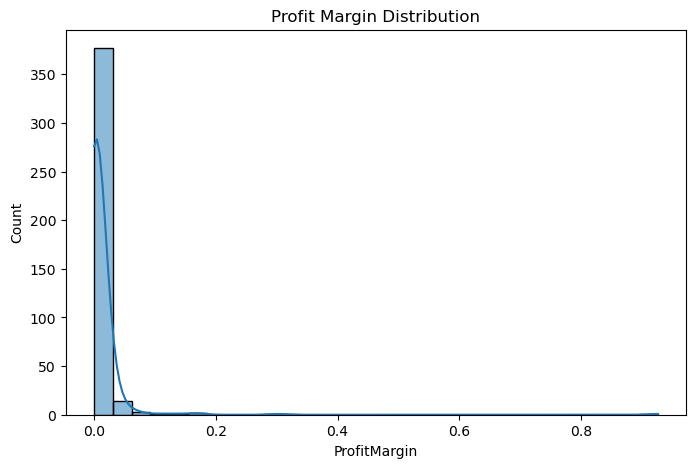

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df['ProfitMargin'], bins=30, kde=True)
plt.title('Profit Margin Distribution')
plt.show()


# 🔥 BONUS (VERY IMPRESSIVE)
🔹 Correlation Heatmap

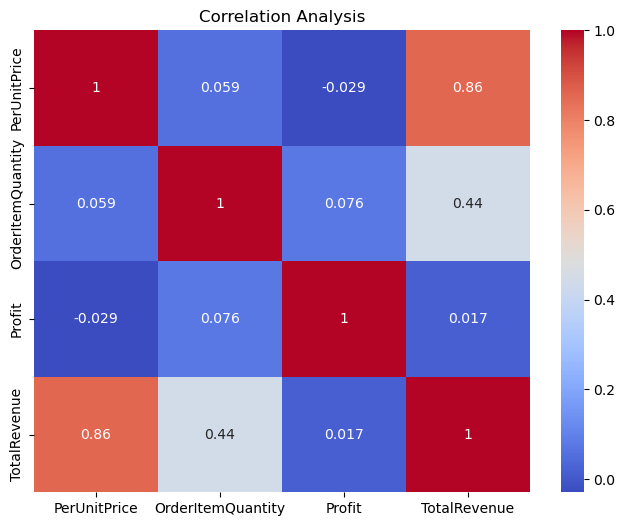

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['PerUnitPrice','OrderItemQuantity','Profit','TotalRevenue']]
    .corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Analysis')
plt.show()


In [34]:
df.column 


AttributeError: 'DataFrame' object has no attribute 'column'